In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from src.get_data import load_data
from src.train.poisson_baseline.baseline_main import (
    fit_poisson_glm,
    fit_poisson_xgboost,
)
from src.train.poisson_nn.nn_main import (
    fit_poisson_nn,
    fit_poisson_nn_transfer_learning,
)
from src.train.utils import run_experiment
from src.visualisation import (
    compare_models_for_cell,
    compare_r2_across_cells,
    journal_plot_pack,
)
from sklearn.preprocessing import StandardScaler

In [3]:
filenames = ["test1.mat", "test2.mat", "test3.mat", "test4.mat"]
X, Y, cell_ids, rec_ids = load_data("../data/simulated", filenames)

In [4]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((5, 60000), (60000,), (60000,), (60000,))

In [5]:
# Baseline models: Poisson GLM with grid search
glm_results = run_experiment(
    "GLM",
    fit_poisson_glm,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir="../data/models",
    base_results_dir="../data/results",
)


===== GLM Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.4315
Train log-likelihood:  11061.93
Train deviance:        6.74
Val pseudo-R²:         0.4740
Val log-likelihood:    2301.52
Val deviance:          6.29
Test pseudo-R²:        0.5115
Test log-likelihood:   3256.04
Test deviance:         7.41

--- Cell 1.0 ---
Train pseudo-R²:       0.4300
Train log-likelihood:  11217.13
Train deviance:        6.87
Val pseudo-R²:         0.4718
Val log-likelihood:    2337.34
Val deviance:          6.26
Test pseudo-R²:        0.5064
Test log-likelihood:   3052.80
Test deviance:         7.29

--- Cell 2.0 ---
Train pseudo-R²:       0.4335
Train log-likelihood:  11268.28
Train deviance:        6.59
Val pseudo-R²:         0.4556
Val log-likelihood:    2273.83
Val deviance:          6.49
Test pseudo-R²:        0.5150
Test log-likelihood:   2831.73
Test deviance:         6.77

--- Cell 3.0 ---
Train pseudo-R²:       0.4229
Train log-likelihood:  10966.56
Train deviance:        6.79
Val pseud

In [6]:
# Poisson XGBoost with grid search
xgboost_results = run_experiment(
    "XGBoost",
    fit_poisson_xgboost,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir="../data/models",
    base_results_dir="../data/results",
)


===== XGBoost Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.8704
Train log-likelihood:  16527.43
Train deviance:        1.54
Val pseudo-R²:         0.8072
Val log-likelihood:    3198.64
Val deviance:          2.31
Test pseudo-R²:        0.7658
Test log-likelihood:   4123.80
Test deviance:         3.55

--- Cell 1.0 ---
Train pseudo-R²:       0.8721
Train log-likelihood:  16809.31
Train deviance:        1.54
Val pseudo-R²:         0.7806
Val log-likelihood:    3161.22
Val deviance:          2.60
Test pseudo-R²:        0.7638
Test log-likelihood:   3908.56
Test deviance:         3.49

--- Cell 2.0 ---
Train pseudo-R²:       0.8702
Train log-likelihood:  16600.22
Train deviance:        1.51
Val pseudo-R²:         0.7785
Val log-likelihood:    3140.46
Val deviance:          2.64
Test pseudo-R²:        0.7634
Test log-likelihood:   3611.92
Test deviance:         3.30

--- Cell 3.0 ---
Train pseudo-R²:       0.8672
Train log-likelihood:  16456.14
Train deviance:        1.56
Val p

In [7]:
glm_results["best_params"]

{0.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 1.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 2.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 3.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 4.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 10.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 11.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 12.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 13.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 14.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 25.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 26.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 27.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 28.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 29.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 45.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {

In [8]:
xgboost_results["best_params"]

{0.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 1.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 2.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 3.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 4.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 10.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 11.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 12.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 13.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
  

In [9]:
# Neural Network hyperparameter grids
nn_model_param_grid = {
    "hidden_sizes": [
        (16,),
        (32,),
        (64,),
        (64, 32),
    ]
}
nn_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4, 1e-3],
}

In [10]:
# Per-cell Neural Network with grid search
nn_results = run_experiment(
    "NN-PerCell",
    fit_poisson_nn,
    {
        "batch_size": "auto",
        "epochs": 30,
        "grid_search": True,
        "k_folds": 2,
        "model_param_grid": nn_model_param_grid,
        "trainer_param_grid": nn_trainer_param_grid,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir="../data/models",
    base_results_dir="../data/results",
)


===== NN-PerCell Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.9121
Train log-likelihood:  17045.89
Train deviance:        1.04
Val pseudo-R²:         0.9139
Val log-likelihood:    3485.97
Val deviance:          1.03
Test pseudo-R²:        0.9064
Test log-likelihood:   4603.25
Test deviance:         1.42

--- Cell 1.0 ---
Train pseudo-R²:       0.9027
Train log-likelihood:  17195.93
Train deviance:        1.17
Val pseudo-R²:         0.8857
Val log-likelihood:    3441.66
Val deviance:          1.36
Test pseudo-R²:        0.8987
Test log-likelihood:   4356.87
Test deviance:         1.50

--- Cell 2.0 ---
Train pseudo-R²:       0.8237
Train log-likelihood:  16031.46
Train deviance:        2.05
Val pseudo-R²:         0.7806
Val log-likelihood:    3145.97
Val deviance:          2.62
Test pseudo-R²:        0.8182
Test log-likelihood:   3784.30
Test deviance:         2.54

--- Cell 3.0 ---
Train pseudo-R²:       0.9075
Train log-likelihood:  16954.45
Train deviance:        1.09
Va

In [11]:
nn_results["best_params"]

{0.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 1.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0001}},
 2.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0001}},
 3.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 4.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 10.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0001}},
 11.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0001}},
 12.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0001}},
 13.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 1e-05}},
 14.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 1e-05}},
 25.0: {'model_params': {'hidden_sizes': (64, 32)},
  't

In [12]:
# Per-cell Neural Network without grid search (for comparison)
nn_nogs_results = run_experiment(
    "NN-PerCell-NoGS",
    fit_poisson_nn,
    {
        "batch_size": "auto",
        "hidden_sizes": [64, 32],
        "l1_lambda": 0.0,
        "grid_search": False,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir="../data/models",
    base_results_dir="../data/results",
)


===== NN-PerCell-NoGS Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.8519
Train log-likelihood:  16297.35
Train deviance:        1.76
Val pseudo-R²:         0.8489
Val log-likelihood:    3311.09
Val deviance:          1.81
Test pseudo-R²:        0.8331
Test log-likelihood:   4353.15
Test deviance:         2.53

--- Cell 1.0 ---
Train pseudo-R²:       0.9073
Train log-likelihood:  17254.32
Train deviance:        1.12
Val pseudo-R²:         0.8934
Val log-likelihood:    3462.31
Val deviance:          1.26
Test pseudo-R²:        0.9026
Test log-likelihood:   4369.76
Test deviance:         1.44

--- Cell 2.0 ---
Train pseudo-R²:       0.8694
Train log-likelihood:  16589.40
Train deviance:        1.52
Val pseudo-R²:         0.8288
Val log-likelihood:    3275.43
Val deviance:          2.04
Test pseudo-R²:        0.8539
Test log-likelihood:   3896.25
Test deviance:         2.04

--- Cell 3.0 ---
Train pseudo-R²:       0.8928
Train log-likelihood:  16773.06
Train deviance:        1.

In [13]:
# Transfer Learning hyperparameter grids
tl_model_param_grid = {
    "hidden_sizes": [
        (16,),
        (32,),
        (64,),
        (64, 32),
    ]
}
tl_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

In [14]:
# Transfer Learning NN with grid search
nn_tl_results = run_experiment(
    "NN-TL",
    fit_poisson_nn_transfer_learning,
    {
        "batch_size": "auto",
        "grid_search": True,
        "model_param_grid": tl_model_param_grid,
        "trainer_param_grid": tl_trainer_param_grid,
        "verbose": True,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir="../data/models",
    base_results_dir="../data/results",
)

TL fit called with 20 cells, 5 features
Starting TL grid search on flattened training set
model_param_grid= {'hidden_sizes': [(16,), (32,), (64,), (64, 32)]}
trainer_param_grid= {'l1_lambda': [0.0, 1e-05, 0.0001]}
training set size: (5, 51000), labels: (51000,)
Evaluating TL combo {'hidden_sizes': (16,)} {'l1_lambda': 0.0}
 -> per-cell median -0.516903352521878
 -> per-cell mean -0.6147667415073481
Evaluating TL combo {'hidden_sizes': (16,)} {'l1_lambda': 1e-05}
 -> per-cell median -0.4175889548541941
 -> per-cell mean -0.5963437043536679
Evaluating TL combo {'hidden_sizes': (16,)} {'l1_lambda': 0.0001}
 -> per-cell median -0.5607954585988173
 -> per-cell mean -0.6410161936528755
Evaluating TL combo {'hidden_sizes': (32,)} {'l1_lambda': 0.0}
 -> per-cell median -0.1955678296429494
 -> per-cell mean -0.38371794812065707
Evaluating TL combo {'hidden_sizes': (32,)} {'l1_lambda': 1e-05}
 -> per-cell median -0.3868554475567919
 -> per-cell mean -0.34302658481421594
Evaluating TL combo {'hid

In [15]:
nn_tl_results["best_params"]

{'model_params': {'hidden_sizes': (64, 32)},
 'trainer_params': {'l1_lambda': 1e-05}}

In [16]:
# Transfer Learning NN without grid search (for comparison)
nn_tl_nogs_results = run_experiment(
    "NN-TL-NoGS",
    fit_poisson_nn_transfer_learning,
    {
        "batch_size": "auto",
        "hidden_sizes": (64, 32),
        "l1_lambda": 0.0001,
        "grid_search": False,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir="../data/models",
    base_results_dir="../data/results",
)


===== NN-TL-NoGS Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1824
Test log-likelihood:   2133.38
Test deviance:         12.40

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.2138
Test log-likelihood:   2080.43
Test deviance:         11.61

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1446
Test log-likelihood:   1668.44
Test deviance:         11.94

--- Cell 3.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1820
Test log-likelihood:   1916.08
Test deviance:         11.78

--- Cell 4.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1607
Test log-likelihood:   1959.11
Test deviance:         12.37

--- Cell 10.0 ---
Train metrics:     

In [17]:
# Prepare comparison data for all models
model_results = [
    (glm_results["results"], "GLM"),
    (xgboost_results["results"], "XGBoost"),
    (nn_results["results"], "NN-PerCell"),
    (nn_tl_results["results"], "NN-TL"),
]

cells = sorted(glm_results["results"].keys())

In [18]:
# Build comparison dataframe with test R2 scores
data_rows = []
for cell in cells:
    row = {"cell": cell}
    for results, name in model_results:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf = pd.DataFrame(data_rows)
df_test_perf

,cell,GLM,XGBoost,NN-PerCell,NN-TL
0,0.0,0.511454,0.765825,0.906368,0.238950
1,1.0,0.506373,0.763823,0.898695,0.208885
2,2.0,0.514983,0.763364,0.818243,0.214673
3,3.0,0.497466,0.759938,0.913273,0.190262
4,4.0,0.501561,0.756861,0.913605,0.153447
5,10.0,0.412066,0.704449,0.784621,0.081010
6,11.0,0.428756,0.716208,0.783584,0.109936
7,12.0,0.467753,0.727279,0.804106,0.048651
8,13.0,0.448820,0.718115,0.794565,0.090678
9,14.0,0.425786,0.684994,0.761742,0.126934


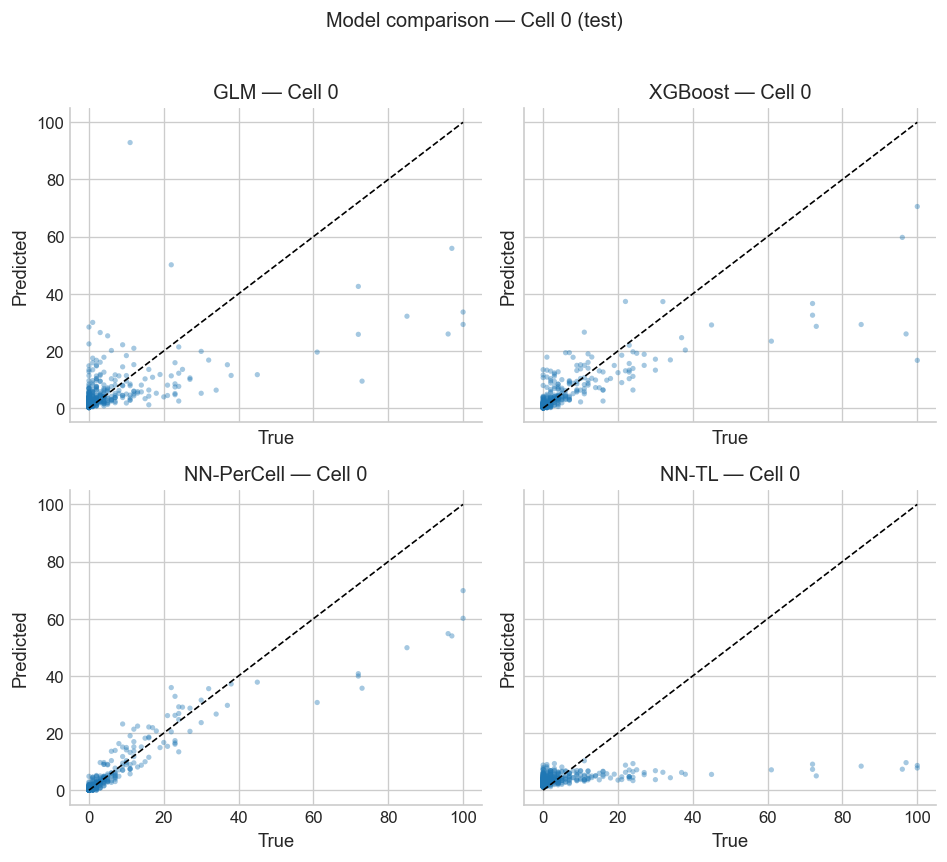

In [19]:
# Compare models for a single cell
compare_models_for_cell(model_results, cell=0, split="test")

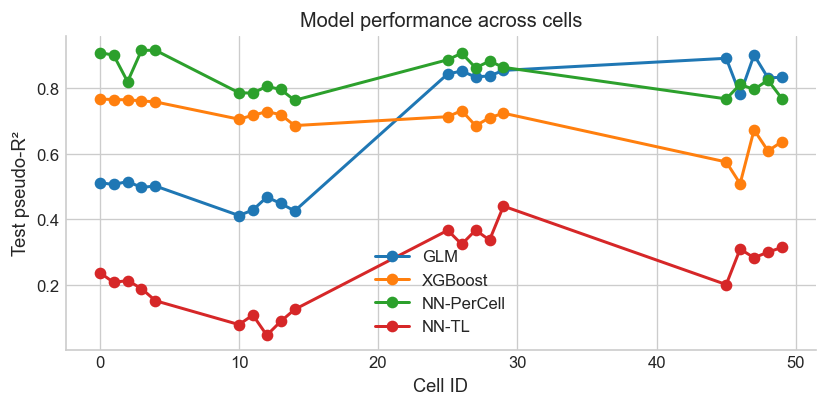

In [20]:
# Summary of R2 across all cells
compare_r2_across_cells(model_results, split="test")

In [21]:
# Generate full journal publication-quality plots for all cells and save them
saved_paths = journal_plot_pack(
    model_results,
    cells=cells,
    split="test",
    base_dir="../data/results/journal",
)
print(f"Generated {len(saved_paths)} plots")
for p in saved_paths[-5:]:
    print(f"  {p}")

Generated 21 plots
  ..\data\results\journal\journal\cell_46.0.png
  ..\data\results\journal\journal\cell_47.0.png
  ..\data\results\journal\journal\cell_48.0.png
  ..\data\results\journal\journal\cell_49.0.png
  ..\data\results\journal\journal\r2_summary.png
